### **1. Data Preparation**

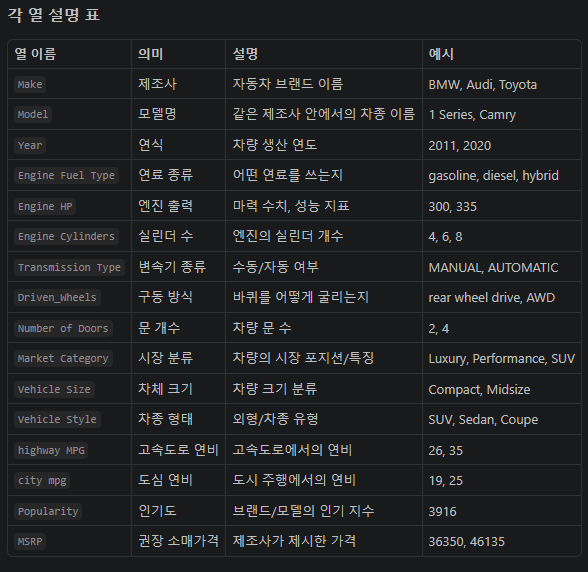

In [ ]:
# %pip install matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url='https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df=pd.read_csv(url)

# Column 값들 소문자,공백은_로 통일하기
df.columns =df.columns.str.lower().str.replace(' ','_')

display(df.head())

# object 타입의 열 찾기
strings = list(df.dtypes[df.dtypes == 'str'].index)
print(strings)

# Column 살펴보기
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']
make
<ArrowStringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str
48

model
<ArrowStringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str
915

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<ArrowStringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<ArrowStringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str
5

driven_wheels
<ArrowStringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3.

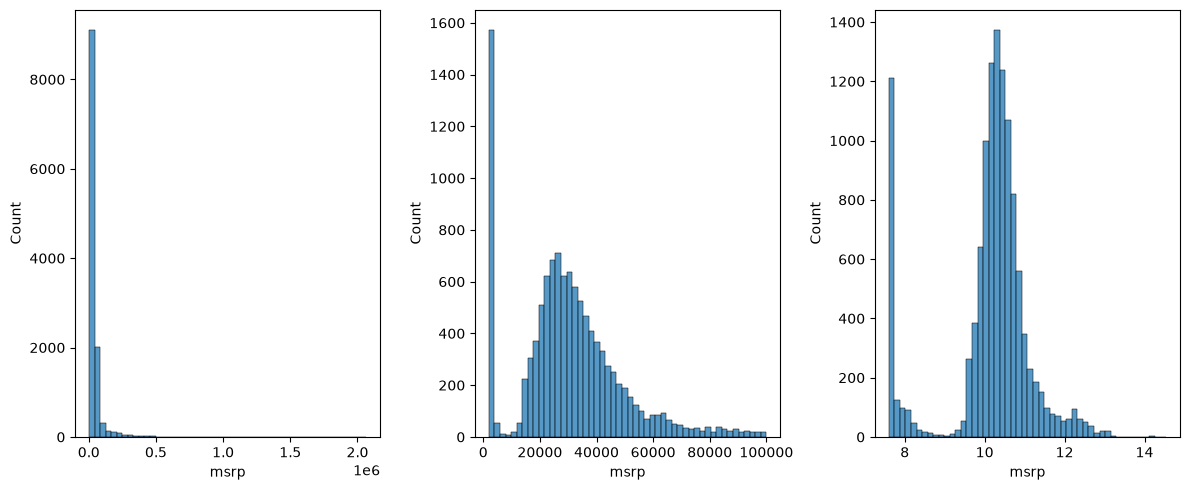

In [ ]:
# 시각화 하기
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.histplot(df.msrp, bins=50, ax=axes[0])
sns.histplot(df.msrp[df.msrp < 100000], bins=50, ax=axes[1])

# lop1p 적용하기 -> 큰값의 영향을 줄여 모델의 안정적인 학습을 도모 (분포를 더 치우치게 만들기)
sns.histplot(np.log1p(df.msrp), bins=50)

plt.tight_layout()
plt.show()

In [ ]:
# 결측치 확인하기
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### **2.Setting Framework**

In [ ]:
# train,valid,test n 정의
n= len(df)
n_train = int(n*0.6)
n_valid = int(n*0.2)
n_test = n-n_train-n_valid

print(n_train,n_valid,n_test)

# part 나누기

